# Configuration


In [1]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import gc
import json
import random
from sklearn.linear_model import LinearRegression, Ridge

In [2]:
# Run this once (only once) everytime you opened jupyter notebook
torch.set_num_threads(1)
torch.set_num_interop_threads(1)

In [3]:
# Set up Random SEED
SEED = 100
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [4]:
# Load parameters for a *specific* stock
# Pick different TICKER to show different inference results
TICKER = "AAPL"
with open(f'../model/tuning/{TICKER}_MASTER_summary.json', 'r') as file:
    tuning_data = json.load(file)
with open(f'../model/ensemble/{TICKER}_ensemble_meta_model.json', 'r') as file:
    ensemble_data = json.load(file)

xgb_best_params = tuning_data['models'][0]['best_params']
lstm_best_params = tuning_data['models'][1]['best_params']
best_alpha = ensemble_data.get('alpha', None)

In [5]:
lstm_best_params

{'seq_len': 3,
 'hidden_dimension': 64,
 'layer_dimension': 2,
 'fc1_dimension': 64,
 'fc2_dimension': 16,
 'dropout': 0,
 'lr': 0.0001,
 'num_epochs': 20,
 'batch_size': 64}

# Build Future Data
### Consider data from 2024-04-03 to 2025-09-16 as the future
### The length of future horizon is exactly a year (365 days)

In [6]:
"""
Load a dataset for a specific stock ticker, split it into past (train) 
and future (test) segments based on a predefined cutoff date, and 
return the processed train/test feature and target matrices.

Args:
    ticker (str, default "AAPL"):
        The stock ticker symbol used to locate the dataset files.
        The function expects two CSV files in the directory:
            ../data/selected/{ticker}_X.csv  (features including a 'date' column)
            ../data/selected/{ticker}_y.csv  (target values)
Returns:
    X_train (np.ndarray): Feature matrix for the training period (shape: [n_train_samples, n_features]).
    X_test (np.ndarray): Feature matrix for the testing period (shape: [n_test_samples, n_features]).
    y_train (np.ndarray): Target vector for the training period (shape: [n_train_samples]).
    y_test (np.ndarray): Target vector for the testing period (shape: [n_test_samples]).
    dates_train (pd.Series): Datetime Series aligned with X_train/y_train.
    dates_test (pd.Series): Datetime Series aligned with X_test/y_test.
"""
def build_past_future_sets(ticker='AAPL'):
    # Load dataset from a specific TICKER
    X_raw = pd.read_csv(f"../data/selected/{ticker}_X.csv")
    y_raw = pd.read_csv(f"../data/selected/{ticker}_y.csv")
    dates = pd.to_datetime(X_raw["date"])
    # Cut off dates
    cutoff = pd.Timestamp("2024-04-03")
    mask = pd.to_datetime(X_raw['date']) < cutoff
    # Split dataset into 'before' (training set) and 'after' (testing set)
    X_train, X_test = X_raw[mask], X_raw[~mask]
    y_train, y_test = y_raw[mask], y_raw[~mask]
    dates_train, dates_test = dates[mask], dates[~mask]
    # Prepare final data
    X_train, X_test = X_train.drop(columns="date").values, X_test.drop(columns="date").values
    y_train, y_test = np.ravel(y_train.values), np.ravel(y_test.values)
    return X_train, X_test, y_train, y_test, dates_train, dates_test

In [7]:
# Example usage
_, _, _, _, _, dates_test = build_past_future_sets(ticker=TICKER)

In [8]:
dates_test

1774   2024-04-03
1775   2024-04-04
1776   2024-04-05
1777   2024-04-08
1778   2024-04-09
          ...    
2134   2025-09-10
2135   2025-09-11
2136   2025-09-12
2137   2025-09-15
2138   2025-09-16
Name: date, Length: 365, dtype: datetime64[ns]

# xgboost inference

In [9]:
'''
Retrain the xgboost model on the entire dataset, and predicts the stock for the upcoming year

Args:
    base_params: the base parameters of the xgboost model
    ticker (str, default "AAPL"): The stock ticker you want to predict.
Returns:
    result: a tuple containing 2 date-indexed pandas series: (1) model predictions (2) actual results
'''
def infer_xgb(base_params=None, ticker='AAPL'):
    # Handle X, y as arrays
    X_train, X_test, y_train, y_test, dates_train, dates_test = build_past_future_sets(ticker)

    # Train model on training data
    reg = xgb.XGBRegressor(**(base_params or {}), random_state=SEED)
    reg.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=50)

    # Predict model on testing data
    y_preds = reg.predict(X_test)

    # Build result pandas series
    predictions = pd.Series(y_preds, index=dates_test)
    actuals = pd.Series(y_test, index=dates_test)
    return predictions, actuals

In [10]:
xgb_preds, xgb_actuals = infer_xgb(base_params=xgb_best_params, ticker=TICKER)

[0]	validation_0-rmse:0.01895	validation_1-rmse:0.01898
[50]	validation_0-rmse:0.01817	validation_1-rmse:0.01895
[100]	validation_0-rmse:0.01763	validation_1-rmse:0.01905
[150]	validation_0-rmse:0.01720	validation_1-rmse:0.01914
[200]	validation_0-rmse:0.01681	validation_1-rmse:0.01918
[250]	validation_0-rmse:0.01642	validation_1-rmse:0.01924
[299]	validation_0-rmse:0.01603	validation_1-rmse:0.01927


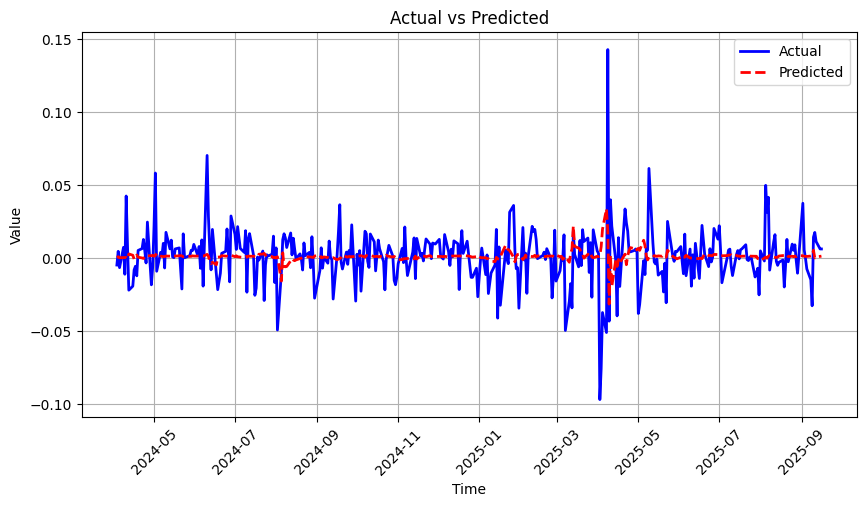

In [11]:
# Plot the actual results vs. model prediction for the most recent period
plt.figure(figsize=(10,5))
plt.plot(xgb_actuals, label='Actual', color='blue', linewidth=2)
plt.plot(xgb_preds, label='Predicted', color='red', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted')
plt.xlabel('Time')
plt.xticks(rotation=45)
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# LSTM inference

In [12]:
# Class Definition
# This is where we fine tune the hyperparameters
class LSTMRegressor(nn.Module):
    def __init__(self, base_params=None):
        super(LSTMRegressor, self).__init__()
        # Default hyperparameters
        defaults = {
            "input_dimension": 20,
            "hidden_dimension": 16,
            "layer_dimension": 1,
            "output_dimension": 1,
            "dropout": 0.1,
            "lr": 0.01,
            "fc1_dimension": 32,
            "fc2_dimension": 16,
            "negative_slope": 0.01,
        }
        
        # Merge user-supplied params with defaults
        if base_params is not None:
            defaults.update(base_params)
        self.params = defaults

        # Extract for convenience
        input_dim   = self.params["input_dimension"]
        hidden_dim  = self.params["hidden_dimension"]
        num_layers  = self.params["layer_dimension"]
        output_dim  = self.params["output_dimension"]
        dropout     = self.params["dropout"]
        fc1_dim     = self.params["fc1_dimension"]
        fc2_dim     = self.params["fc2_dimension"]
        neg_slope   = self.params["negative_slope"]

        # --- Define LSTM layer ---
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # --- Define MLP head with LeakyReLU + Dropout in one Sequential ---
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, fc1_dim),
            nn.LeakyReLU(negative_slope=neg_slope),
            nn.Dropout(dropout),

            nn.Linear(fc1_dim, fc2_dim),
            nn.LeakyReLU(negative_slope=neg_slope),
            
            nn.Linear(fc2_dim, output_dim),
        )

    def forward(self, x, h0=None, c0=None):
        """
        x: (B, L, F)        
        """

        # Initialize hidden/cell states if not provided
        if h0 is None or c0 is None:
            h0 = torch.zeros(self.params["layer_dimension"], x.size(0), self.params["hidden_dimension"])
            c0 = torch.zeros(self.params["layer_dimension"], x.size(0), self.params["hidden_dimension"])

        # Pass through LSTM: out -> (B, L, H)
        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]   # last timestep: (B, H)

        # Pass through MLP head
        out = self.mlp(out)   # (B, output_dim)

        return out.squeeze(-1)

In [13]:
def infer_lstm(base_params=None, ticker="AAPL"):
    """
    Retrain the LSTM model on historical data and predict the stock for the upcoming period.

    Args:
        base_params: dict of hyperparameters for LSTMRegressor
        ticker (str, default "AAPL"): The stock ticker you want to predict.

    Returns:
        predictions: pd.Series of model predictions (indexed by dates)
        actuals: pd.Series of actual values (indexed by dates)
    """

    X_train, X_test, y_train, y_test, dates_train, dates_test = build_past_future_sets(ticker)

    # --- Default values & params ---
    defaults = {"seq_len": 3, "num_epochs": 15, "batch_size": 32}
    params = {**defaults, **(base_params or {})}

    L = params["seq_len"]
    epochs = params["num_epochs"]
    batch_size = params["batch_size"]

    # --- Coerce to numpy arrays ---
    X_train = np.asarray(X_train, dtype=np.float32)
    X_test = np.asarray(X_test, dtype=np.float32)
    y_train = np.asarray(y_train, dtype=np.float32).reshape(-1)
    y_test  = np.asarray(y_test, dtype=np.float32).reshape(-1)

    # --- Build training sequences ---
    N_seq = len(X_train) - L
    if N_seq <= 0:
        raise ValueError(f"Not enough training data for seq_len={L}")

    print(f"[Infer-LSTM] Building {N_seq} training sequences...")

    X_train_seqs = []
    y_train_targets = []

    for i in range(N_seq):
        X_train_seqs.append(X_train[i : i + L])
        y_train_targets.append(y_train[i + L])

    X_train_seqs = torch.from_numpy(np.asarray(X_train_seqs, dtype=np.float32))
    y_train_targets = torch.from_numpy(np.asarray(y_train_targets, dtype=np.float32))

    # --- Initialize model ---
    model = LSTMRegressor(params)
    criterion = nn.MSELoss()
    lr = params.get("lr", 1e-3)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # --- Training loop ---
    model.train()
    for epoch in range(epochs):
        total_loss = 0.0

        for start in range(0, N_seq, batch_size):
            end = start + batch_size
            x_batch = X_train_seqs[start:end]
            y_batch = y_train_targets[start:end]

            optimizer.zero_grad(set_to_none=True)
            y_pred = model(x_batch).view(-1)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += float(loss.detach()) * len(x_batch)

        rmse = (total_loss / max(N_seq, 1)) ** 0.5
        print(f"[Infer-LSTM] Epoch {epoch+1}/{epochs} | Train RMSE: {rmse:.4f}")

    # --- Inference ---
    model.eval()
    X_all = np.concatenate([X_train, X_test], axis=0)

    preds = []
    offset = len(X_train)

    with torch.no_grad():
        for k in range(len(X_test)):
            idx_global = offset + k
            x_seq = torch.as_tensor(X_all[idx_global - L : idx_global], dtype=torch.float32).unsqueeze(0)
            y_hat = model(x_seq).view(-1)[0].item()
            preds.append(y_hat)

    preds = np.asarray(preds, dtype=np.float32)

    dates_test = pd.to_datetime(pd.Series(dates_test))
    predictions = pd.Series(preds, index=dates_test)
    actuals     = pd.Series(y_test, index=dates_test)

    return predictions, actuals

In [14]:
lstm_preds, lstm_actuals = infer_lstm(base_params=lstm_best_params, ticker=TICKER)

[Infer-LSTM] Building 1771 training sequences...
[Infer-LSTM] Epoch 1/20 | Train RMSE: 0.0519
[Infer-LSTM] Epoch 2/20 | Train RMSE: 0.0317
[Infer-LSTM] Epoch 3/20 | Train RMSE: 0.0210
[Infer-LSTM] Epoch 4/20 | Train RMSE: 0.0193
[Infer-LSTM] Epoch 5/20 | Train RMSE: 0.0192
[Infer-LSTM] Epoch 6/20 | Train RMSE: 0.0191
[Infer-LSTM] Epoch 7/20 | Train RMSE: 0.0190
[Infer-LSTM] Epoch 8/20 | Train RMSE: 0.0190
[Infer-LSTM] Epoch 9/20 | Train RMSE: 0.0190
[Infer-LSTM] Epoch 10/20 | Train RMSE: 0.0190
[Infer-LSTM] Epoch 11/20 | Train RMSE: 0.0190
[Infer-LSTM] Epoch 12/20 | Train RMSE: 0.0190
[Infer-LSTM] Epoch 13/20 | Train RMSE: 0.0190
[Infer-LSTM] Epoch 14/20 | Train RMSE: 0.0190
[Infer-LSTM] Epoch 15/20 | Train RMSE: 0.0189
[Infer-LSTM] Epoch 16/20 | Train RMSE: 0.0189
[Infer-LSTM] Epoch 17/20 | Train RMSE: 0.0189
[Infer-LSTM] Epoch 18/20 | Train RMSE: 0.0189
[Infer-LSTM] Epoch 19/20 | Train RMSE: 0.0189
[Infer-LSTM] Epoch 20/20 | Train RMSE: 0.0189


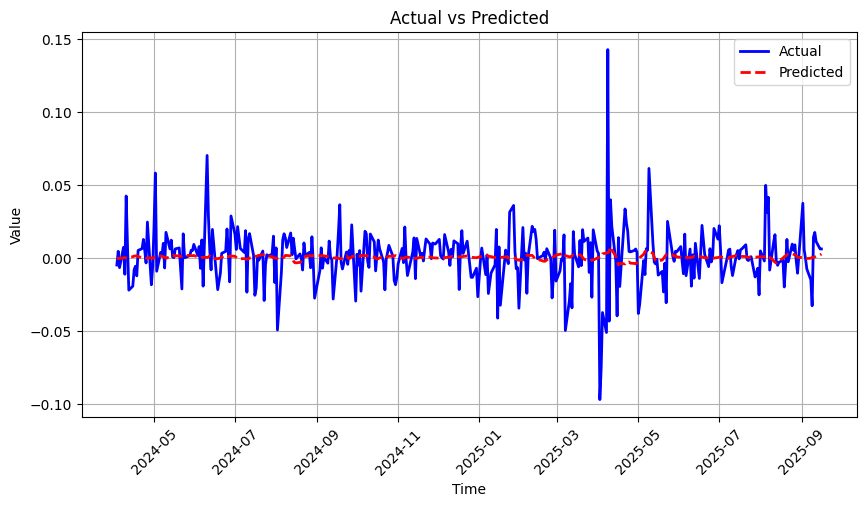

In [15]:
# Plot the actual results vs. model prediction for the most recent period
plt.figure(figsize=(10,5))
plt.plot(lstm_actuals, label='Actual', color='blue', linewidth=2)
plt.plot(lstm_preds, label='Predicted', color='red', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted')
plt.xlabel('Time')
plt.xticks(rotation=45)
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# Ensemble Inference


In [16]:
"""
Run inference with an ensemble of XGB and LSTM models.

Args:
    xgb_params: dict of hyperparameters for XGBRegressor (passed to infer_xgb)
    lstm_params: dict of hyperparameters for LSTMRegressor (passed to infer_lstm)
    alpha: regularization strength for Ridge. If None, use plain LinearRegression.
    ticker (str): stock ticker

Returns:
    predictions: pd.Series of ensemble predictions (indexed by dates)
    actuals:     pd.Series of actual target values (same index)
"""

def infer_ensemble_model(xgb_params=None, lstm_params=None, alpha=None, ticker="AAPL"):
    # --- 1. Get base model predictions (same interface as infer_xgb) ---
    xgb_preds, xgb_actuals   = infer_xgb(base_params=xgb_params, ticker=TICKER)
    lstm_preds, lstm_actuals = infer_lstm(base_params=lstm_params, ticker=TICKER)

    # --- 2. Align by date index (inner join to be safe) ---
    df = pd.concat(
        [
            xgb_preds.rename("xgb_pred"),
            lstm_preds.rename("lstm_pred"),
            xgb_actuals.rename("y"),
            # you could also check lstm_actuals, but they should match xgb_actuals
        ],
        axis=1,
        join="inner",
    ).dropna()

    X_meta = df[["xgb_pred", "lstm_pred"]].values  # shape: (n_samples, 2)
    y_meta = df["y"].values                        # shape: (n_samples,)

    # --- 3. Create meta-model: LinearRegression or Ridge ---
    if alpha is None:
        meta_model = LinearRegression()
    else:
        meta_model = Ridge(alpha=alpha)

    meta_model.fit(X_meta, y_meta)

    # --- 4. Ensemble predictions and return as Series ---
    y_ens = meta_model.predict(X_meta)

    predictions = pd.Series(y_ens, index=df.index, name="ensemble_pred")
    actuals = df["y"]

    return predictions, actuals

In [17]:
ensemble_preds, ensemble_actuals = infer_ensemble_model(xgb_params=xgb_best_params, lstm_params=lstm_best_params,
                                                        alpha=best_alpha, ticker=TICKER)

[0]	validation_0-rmse:0.01895	validation_1-rmse:0.01898
[50]	validation_0-rmse:0.01817	validation_1-rmse:0.01895
[100]	validation_0-rmse:0.01763	validation_1-rmse:0.01905
[150]	validation_0-rmse:0.01720	validation_1-rmse:0.01914
[200]	validation_0-rmse:0.01681	validation_1-rmse:0.01918
[250]	validation_0-rmse:0.01642	validation_1-rmse:0.01924
[299]	validation_0-rmse:0.01603	validation_1-rmse:0.01927
[Infer-LSTM] Building 1771 training sequences...
[Infer-LSTM] Epoch 1/20 | Train RMSE: 0.1138
[Infer-LSTM] Epoch 2/20 | Train RMSE: 0.0910
[Infer-LSTM] Epoch 3/20 | Train RMSE: 0.0685
[Infer-LSTM] Epoch 4/20 | Train RMSE: 0.0460
[Infer-LSTM] Epoch 5/20 | Train RMSE: 0.0278
[Infer-LSTM] Epoch 6/20 | Train RMSE: 0.0210
[Infer-LSTM] Epoch 7/20 | Train RMSE: 0.0200
[Infer-LSTM] Epoch 8/20 | Train RMSE: 0.0195
[Infer-LSTM] Epoch 9/20 | Train RMSE: 0.0193
[Infer-LSTM] Epoch 10/20 | Train RMSE: 0.0192
[Infer-LSTM] Epoch 11/20 | Train RMSE: 0.0191
[Infer-LSTM] Epoch 12/20 | Train RMSE: 0.0191
[Infe

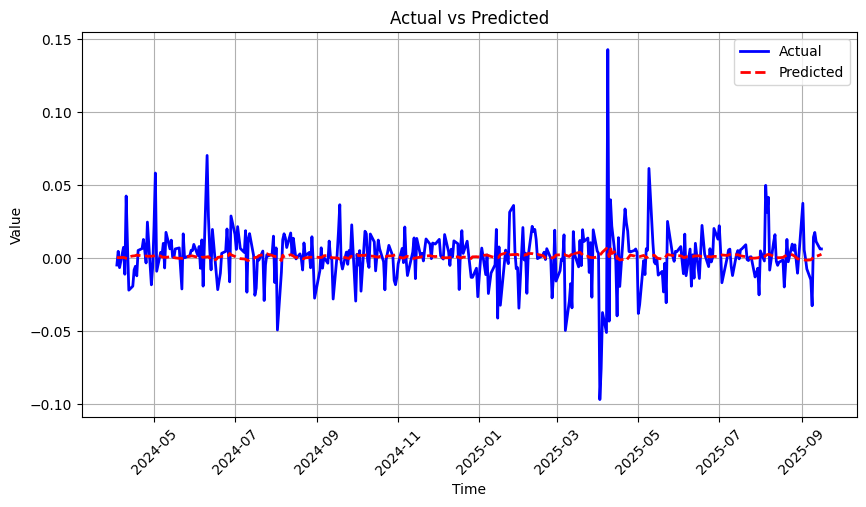

In [18]:
# Plot the actual results vs. model prediction for the most recent period
plt.figure(figsize=(10,5))
plt.plot(ensemble_actuals, label='Actual', color='blue', linewidth=2)
plt.plot(ensemble_preds, label='Predicted', color='red', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted')
plt.xlabel('Time')
plt.xticks(rotation=45)
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()